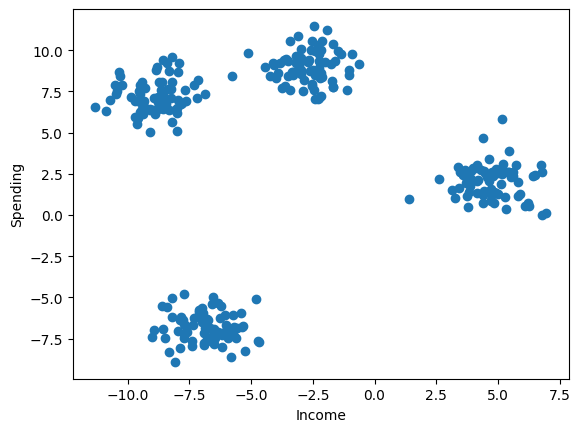

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)
df = pd.DataFrame(X, columns=['income', 'spending'])
plt.scatter(x='income', y='spending', data=df)
plt.xlabel('Income')
plt.ylabel('Spending')
plt.show()

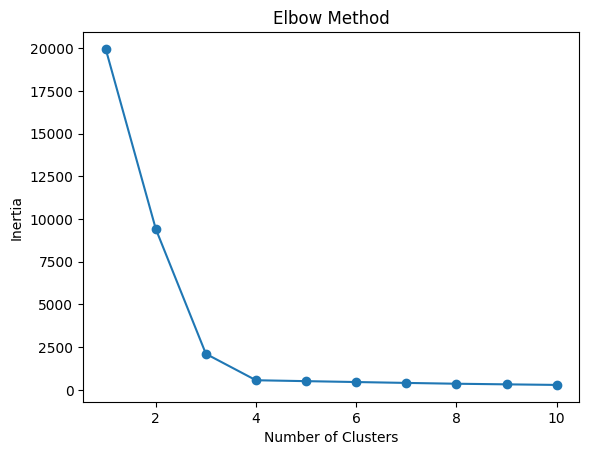

In [11]:
from sklearn.cluster import KMeans

inertias = []
K_Range = range(1, 11)

for k in K_Range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(df)
  inertias.append(kmeans.inertia_)

plt.plot(K_Range, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [12]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['clusters'] = km.fit_predict(df[['income', 'spending']])
df.head()

,income,spending,clusters
0,-9.297689,6.473679,3
1,-9.698741,6.938967,3
2,-1.686653,7.793442,0
3,-7.097308,-5.781333,1
4,-10.876452,6.315437,3


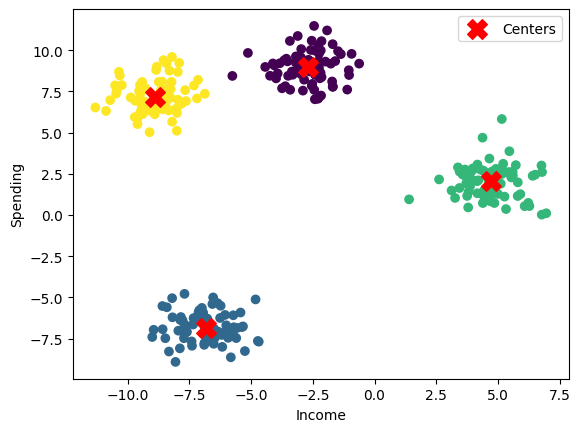

In [16]:
plt.scatter(df['income'], df['spending'], c=df['clusters'], cmap='viridis')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='red', marker='X', label='Centers', s=200)
plt.legend()
plt.xlabel('Income')
plt.ylabel('Spending')
plt.show()